<a href="https://colab.research.google.com/github/diemacedo12/final-project/blob/main/Final_project_draft_(2nd_version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing packages

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from itertools import combinations

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Loading dataset

In [ ]:
df = pd.read_csv('/content/ufo_sightings.csv')
print(f"Total UFO reports: {len(df)}")

Total UFO reports: 80332


Text Preprocessing

In [ ]:
def preprocess(text):
    text = clean_text(text)

    # Simple tokenization using split
    tokens = text.split()

    # Remove stopwords and short words + lemmatize
    tokens = [lemmatizer.lemmatize(word)
              for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing
df['clean_description'] = df['description'].apply(clean_text)
df['processed'] = df['clean_description'].apply(preprocess)

print("Preprocessing completed successfully!")
print(df[['description', 'processed']].head())

Preprocessing completed successfully!
                                         description  \
0  This event took place in early fall around 194...   
1  1949 Lackland AFB&#44 TX.  Lights racing acros...   
2  Green/Orange circular disc over Chester&#44 En...   
3  My older brother and twin sister were leaving ...   
4  AS a Marine 1st Lt. flying an FJ4B fighter/att...   

                                           processed  
0  event took place early fall around occurred bo...  
1  lackland afb light racing across sky amp makin...  
2          greenorange circular disc chester england  
3  older brother twin sister leaving edna theater...  
4  marine flying fjb fighterattack aircraft solo ...  


Topic Modeling (LDA)



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
vectorizer = CountVectorizer(max_df=0.95, min_df=10, stop_words='english')
dtm = vectorizer.fit_transform(df['processed'])

In [ ]:
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=8, random_state=42)

In [ ]:
feature_names = vectorizer.get_feature_names_out()

print("\n=== Topics Found ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-12:-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")


=== Topics Found ===
Topic 0: light, craft, triangle, flying, triangular, formation, large, sound, low, object, silent
Topic 1: light, sky, moving, bright, orange, red, white, ball, night, object, fast
Topic 2: light, ufo, note, nuforc, sighting, seen, bright, possible, near, sky, orange
Topic 3: light, bright, object, speed, high, sky, moving, white, direction, north, disappeared
Topic 4: driving, saw, ufo, witness, home, time, road, north, car, west, south
Topic 5: like, star, saw, looked, sky, looking, outside, night, object, light, noticed
Topic 6: object, sky, seen, fireball, orange, large, glowing, flying, sphere, silver, orb
Topic 7: light, object, shaped, shape, red, hovering, craft, oval, white, blue, bright


Network Analysis / Word Co-occurrence Network



In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
all_words = ' '.join(df['processed']).split()
word_freq = Counter(all_words)
top_words = [word for word, freq in word_freq.most_common(50)]

In [ ]:
G = nx.Graph()

for text in df['processed']:
    words_in_doc = [w for w in text.split() if w in top_words]
    for word1, word2 in combinations(set(words_in_doc), 2): #Avoiding duplicates
        if G.has_edge(word1, word2):
            G[word1][word2]['weight'] += 1
        else:
            G.add_edge(word1, word2, weight=1)

Network image saved as network.png - Use this in your poster!


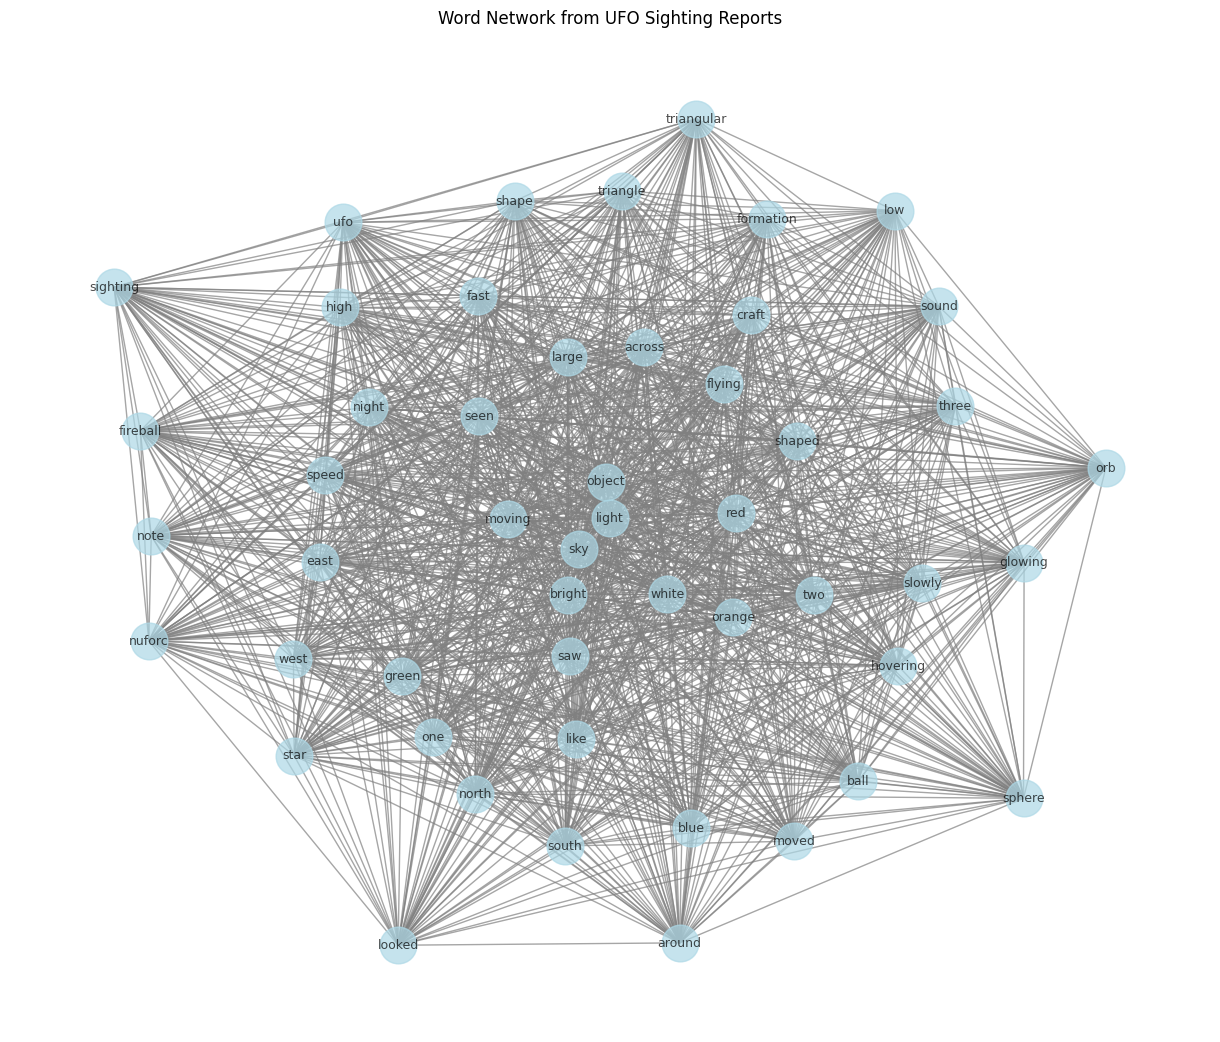

In [ ]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.6)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue',
        font_size=9, edge_color='gray', alpha=0.7)
plt.title("Word Network from UFO Sighting Reports")
plt.savefig("network.png", dpi=300, bbox_inches='tight')
print("Network image saved as network.png - Use this in your poster!")

Visualizations with Altair



In [ ]:
import altair as alt

top15 = pd.DataFrame(word_freq.most_common(15), columns=['word', 'count'])

chart = alt.Chart(top15).mark_bar(color='steelblue').encode(
    x=alt.X('count:Q', title='Frequency'),
    y=alt.Y('word:N', sort='-x', title='Word')
).properties(
    title='Most Common Words in UFO Reports',
    width=600,
    height=400
)

chart.display()

alt.Chart(...)